# Fractal swing labels (L/R) - build and inspect

Purpose:
- generate offline fractal swing labels from clean OHLC data
- visualize the labels before saving them for model training

Input:
- `ETHUSDT_15m_ohlc_clean.parquet`

Output:
- `ETHUSDT_15m_fractal_labels_L10_R10.parquet`

Reading guide:
1. Define the labeling rule with left and right windows.
2. Build `y_high` and `y_low` for each bar.
3. Merge labels back onto OHLC for plotting.
4. Save only the label columns needed downstream.
5. Inspect both full-window and zoomed plots.

Important note:
- Fractal labels are intentionally offline targets. A label at bar `t` becomes knowable online only after bar `t + R`.


In [ ]:
# Centralize file locations here so folder changes are handled in one place.

import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path

def locate_ml_root(start=None) -> Path:
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for candidate in [start] + list(start.parents):
        if candidate.name == "ML v1" and (candidate / "data").exists():
            return candidate

        ml_root = candidate / "ML v1"
        if (ml_root / "data").exists() and (ml_root / "code").exists():
            return ml_root

    raise FileNotFoundError(
        "Could not locate the 'ML v1' workspace from the current working directory."
    )


ML_ROOT = locate_ml_root()
PROJECT_ROOT = ML_ROOT.parent
DATA_DIR = ML_ROOT / "data"
CONFIG_DIR = ML_ROOT / "configs"
CODE_DIR = ML_ROOT / "code"

OHLC_PATH = DATA_DIR / "ETHUSDT_15m_ohlc_clean.parquet"
OUTPUT_LABELS_PATH = DATA_DIR / "ETHUSDT_15m_fractal_labels_L10_R10.parquet"

# ---------- Fractal window ----------
L = 10
R = 10

# ---------- Plot windows ----------
VIEW_LAST_N_BARS = 2000
ZOOM_LAST_N_BARS = 400


## 1) Labeling functions

In [8]:
# The centered rolling window creates offline labels; confirmation timing is tracked separately through confirm_shift and confirm_timestamp.

@dataclass(frozen=True)
class FractalLabelConfig:
    """
    Offline future-extremum (fractal) labeling configuration.

    swing_high[t] = 1 if High[t] == max(High[t-L : t+R])
    swing_low[t]  = 1 if Low[t]  == min(Low[t-L  : t+R])

    Notes:
        - OFFLINE labeling (future bars allowed for targets only).
        - Online: a swing at t is confirmable only at t + R.
    """
    left: int = 10
    right: int = 10
    timestamp_col: str = "timestamp"
    segment_col: str = "segment_id"
    high_col: str = "high"
    low_col: str = "low"


def label_fractal_swings(df: pd.DataFrame, cfg: FractalLabelConfig) -> pd.DataFrame:
    """
    Label swing highs/lows using a centered rolling window per segment.

    Args:
        df: OHLC dataframe. Required columns: [high, low].
            Recommended: [timestamp, segment_id].
        cfg: labeling config (L/R window, column names).

    Returns:
        DataFrame with:
            - timestamp (if present)
            - segment_id (if present)
            - y_high (int8)
            - y_low (int8)
            - confirm_shift (int = cfg.right)
            - confirm_timestamp (if timestamp present; only on labeled rows)
    """
    if cfg.left <= 0 or cfg.right <= 0:
        raise ValueError(f"left/right must be > 0, got left={cfg.left}, right={cfg.right}")

    for col in (cfg.high_col, cfg.low_col):
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    window = cfg.left + cfg.right + 1

    keep_cols = []
    if cfg.timestamp_col in df.columns:
        keep_cols.append(cfg.timestamp_col)
    if cfg.segment_col in df.columns:
        keep_cols.append(cfg.segment_col)

    out = df[keep_cols].copy() if keep_cols else pd.DataFrame(index=df.index)
    out["confirm_shift"] = int(cfg.right)
    out["y_high"] = 0
    out["y_low"] = 0

    if cfg.segment_col in df.columns:
        groups = df.groupby(cfg.segment_col, sort=False)
    else:
        groups = [(None, df)]

    for _, g in groups:
        idx = g.index

        highs = pd.to_numeric(g[cfg.high_col], errors="coerce")
        lows = pd.to_numeric(g[cfg.low_col], errors="coerce")

        roll_max = highs.rolling(window=window, center=True, min_periods=window).max()
        roll_min = lows.rolling(window=window, center=True, min_periods=window).min()

        y_high = (highs == roll_max).astype("int64").fillna(0)
        y_low = (lows == roll_min).astype("int64").fillna(0)

        out.loc[idx, "y_high"] = y_high.values
        out.loc[idx, "y_low"] = y_low.values

        if cfg.timestamp_col in df.columns:
            ts = g[cfg.timestamp_col]
            confirm_ts = ts.shift(-cfg.right)

            mask_any = (y_high == 1) | (y_low == 1)
            masked = pd.Series(pd.NaT, index=idx)
            masked.loc[mask_any] = confirm_ts.loc[mask_any]
            out.loc[idx, "confirm_timestamp"] = masked.values

    out["y_high"] = out["y_high"].astype("int8")
    out["y_low"] = out["y_low"].astype("int8")
    return out


## 2) Load OHLC + build labels

In [ ]:
# Print the label counts early so sparsity looks reasonable before plotting or saving.

ohlc = pd.read_parquet(OHLC_PATH)
print("OHLC:", ohlc.shape, "columns:", list(ohlc.columns))

cfg = FractalLabelConfig(left=L, right=R)
labels = label_fractal_swings(ohlc, cfg)

print("\nLabels:", labels.shape, "columns:", list(labels.columns))
print("Total swing_high:", int((labels["y_high"] == 1).sum()))
print("Total swing_low :", int((labels["y_low"] == 1).sum()))


## 3) Merge labels onto OHLC (for plotting)

In [10]:
if "timestamp" in ohlc.columns and "timestamp" in labels.columns:
    on_cols = ["timestamp"]
    if "segment_id" in ohlc.columns and "segment_id" in labels.columns:
        on_cols.append("segment_id")
    df = ohlc.merge(labels, on=on_cols, how="left", validate="one_to_one")
else:
    df = ohlc.copy()
    for col in ["y_high", "y_low", "confirm_shift", "confirm_timestamp"]:
        if col in labels.columns:
            df[col] = labels[col].values

if "timestamp" in df.columns:
    df = df.sort_values("timestamp")

df_view = df.tail(VIEW_LAST_N_BARS).copy()
print("View window rows:", len(df_view))


View window rows: 2000


## 4) Save labels (optional)

In [ ]:
# Save only the label contract required by downstream training notebooks.

# Save ONLY labels (timestamp + segment_id + targets [+ optional confirm fields])
cols = []

# keys
if "timestamp" in labels.columns:
    cols.append("timestamp")
if "segment_id" in labels.columns:
    cols.append("segment_id")

# targets
cols += ["y_high", "y_low"]

labels_out = labels[cols].copy()
labels_out.to_parquet(OUTPUT_LABELS_PATH, index=False)

print("Saved labels-only parquet:", OUTPUT_LABELS_PATH)
print("Columns:", cols)
print("Rows:", len(labels_out))


## 5) Plot: Close + swing markers (overview)

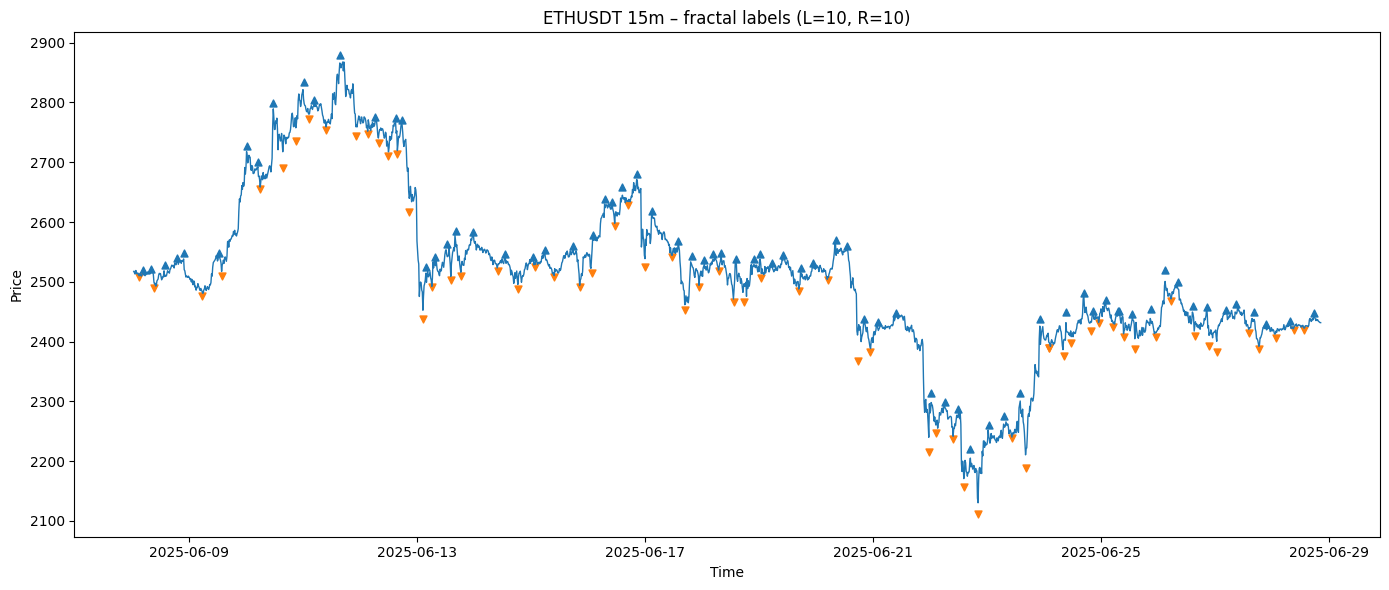

In [12]:
x = df_view["timestamp"] if "timestamp" in df_view.columns else df_view.index
is_high = df_view["y_high"] == 1
is_low = df_view["y_low"] == 1

plt.figure(figsize=(14, 6))
plt.plot(x, df_view["close"], linewidth=1)
plt.scatter(x[is_high], df_view.loc[is_high, "high"], s=25, marker="^")
plt.scatter(x[is_low], df_view.loc[is_low, "low"], s=25, marker="v")

plt.title(f"ETHUSDT 15m – fractal labels (L={L}, R={R})")
plt.xlabel("Time")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


## 6) Plot: Zoomed window with wick ranges

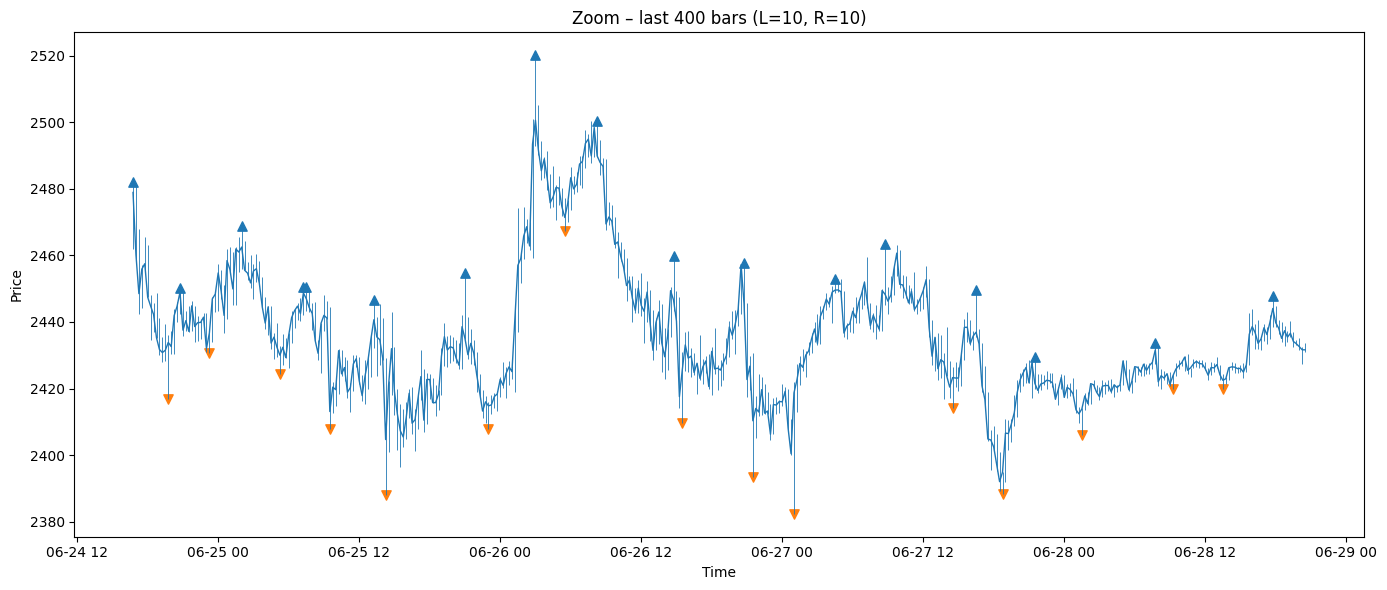

In [13]:
df_zoom = df_view.tail(ZOOM_LAST_N_BARS).copy()
x = df_zoom["timestamp"] if "timestamp" in df_zoom.columns else df_zoom.index

plt.figure(figsize=(14, 6))
plt.vlines(x, df_zoom["low"], df_zoom["high"], linewidth=0.6)
plt.plot(x, df_zoom["close"], linewidth=1)

is_high = df_zoom["y_high"] == 1
is_low = df_zoom["y_low"] == 1
plt.scatter(x[is_high], df_zoom.loc[is_high, "high"], s=45, marker="^")
plt.scatter(x[is_low], df_zoom.loc[is_low, "low"], s=45, marker="v")

plt.title(f"Zoom – last {ZOOM_LAST_N_BARS} bars (L={L}, R={R})")
plt.xlabel("Time")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


## 7) Inspect last labeled swings

In [14]:
cols = [c for c in ["timestamp", "open", "high", "low", "close", "segment_id", "y_high", "y_low", "confirm_timestamp"] if c in df.columns]
df[df["y_high"].eq(1) | df["y_low"].eq(1)][cols].tail(30)


,timestamp,open,high,low,close,segment_id,y_high,y_low,confirm_timestamp
138835,2025-06-24 20:45:00+00:00,2444.74,2450.30,2442.35,2448.96,1,1,0,2025-06-24 23:15:00+00:00
138845,2025-06-24 23:15:00+00:00,2432.04,2436.80,2430.55,2436.70,1,0,1,2025-06-25 01:45:00+00:00
138856,2025-06-25 02:00:00+00:00,2461.01,2468.77,2456.00,2462.51,1,1,0,2025-06-25 04:30:00+00:00
138869,2025-06-25 05:15:00+00:00,2432.42,2432.78,2424.30,2430.03,1,0,1,2025-06-25 07:45:00+00:00
138877,2025-06-25 07:15:00+00:00,2442.53,2450.63,2442.05,2448.75,1,1,0,2025-06-25 09:45:00+00:00
138878,2025-06-25 07:30:00+00:00,2448.75,2450.63,2443.26,2446.96,1,1,0,2025-06-25 10:00:00+00:00
138886,2025-06-25 09:30:00+00:00,2441.19,2444.38,2407.94,2413.11,1,0,1,2025-06-25 12:00:00+00:00
138901,2025-06-25 13:15:00+00:00,2434.97,2446.68,2432.10,2440.68,1,1,0,2025-06-25 15:45:00+00:00
138905,2025-06-25 14:15:00+00:00,2429.10,2429.20,2388.00,2404.70,1,0,1,2025-06-25 16:45:00+00:00
138932,2025-06-25 21:00:00+00:00,2438.59,2454.81,2434.89,2435.07,1,1,0,2025-06-25 23:30:00+00:00
